# Vector Search 101 — Practical

**Module:** Retrieval-Augmented Generation & Multimodal Systems  
**Practical goal:** build the retrieval primitives that later power full RAG systems.

In earlier sessions, the focus was on LLM behaviour, prompting, reasoning loops, and agent workflows. This practical shifts to a new question:

> How can software search by meaning rather than only by exact words?

You will build:

1. a sparse keyword baseline,
2. dense embeddings with `sentence-transformers`,
3. similarity comparisons,
4. an in-memory FAISS vector index,
5. sparse vs dense vs hybrid retrieval comparisons,
6. a small precision@k retrieval evaluation.

The notebook intentionally stops before full RAG. The next sessions add vector databases, document chunking, generation, and RAG evaluation.

## Setup

The main practical is local and free. The optional OpenAI section runs only if `OPENAI_API_KEY` is configured.

**COST NOTE:** Default run is `$0`. The optional hosted embedding comparison uses a tiny number of tokens and is typically far below `$0.01`.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sklearn.metrics.pairwise import cosine_similarity

from utils import (
    build_faiss_index,
    build_tfidf_index,
    dense_search,
    embed_texts,
    estimate_openai_embedding_cost,
    evaluate_retriever,
    hybrid_search,
    keyword_search,
    load_labelled_queries,
    load_sentence_embedding_model,
    load_support_articles,
    openai_embed_texts,
    results_from_indices,
    search_faiss,
)

load_dotenv()

DATA_DIR = Path("data")
ARTICLES_PATH = DATA_DIR / "support_articles.csv"
QUERIES_PATH = DATA_DIR / "labelled_queries.csv"

pd.set_option("display.max_colwidth", 120)
print("Setup complete.")

Setup complete.


## 1. Load the mini knowledge base

This practical uses a small customer-support knowledge base. Small data is useful for teaching because every ranking mistake can be inspected manually.

In [2]:
articles = load_support_articles(ARTICLES_PATH)
labelled_queries = load_labelled_queries(QUERIES_PATH)

print(f"Articles: {len(articles)}")
print(f"Labelled queries: {len(labelled_queries)}")

articles[["doc_id", "title", "category", "text"]].head(8)

Articles: 26
Labelled queries: 10


,doc_id,title,category,text
0,KB-001,Reset a forgotten password,Account Access,"Use password recovery when you cannot sign in. Click Forgot Password, verify your email, then create a new password...."
1,KB-002,Unlock an account after failed login attempts,Account Access,"If your account is locked after too many failed sign-in attempts, wait 15 minutes or contact support to unlock it. P..."
2,KB-003,Change the phone used for two-factor authentication,Security,"When you change phones, update two-factor authentication from Security Settings before wiping the old device. If you..."
3,KB-004,Request a refund for a cancelled subscription,Billing,Refunds are available for cancelled subscriptions within 14 days of purchase if usage is below the fair-use threshol...
4,KB-005,Update payment method after card failure,Billing,"If a card payment fails, add a new payment method under Billing Settings. The system retries the invoice automatical..."
5,KB-006,Understand invoice tax details,Billing,"Invoices show tax identification number, billing address, taxable amount, and local tax. Update billing details befo..."
6,KB-007,Track an order that has not arrived,Orders,"Use the shipment tracking link in your order confirmation email. If tracking has not updated for 48 hours, contact l..."
7,KB-008,Change delivery address before dispatch,Orders,"Delivery address changes are possible only before warehouse dispatch. After dispatch, the courier must handle rerout..."


## 2. Sparse keyword search baseline

Keyword retrieval is called **sparse retrieval** because each document is represented mostly by zeros over a large vocabulary. TF-IDF is not a production search engine, but it is a perfect classroom baseline.

Watch for two behaviours:

- exact terms such as error codes should work well,
- paraphrases may fail because the words differ.

In [3]:
vectorizer, tfidf_matrix = build_tfidf_index(articles["searchable_text"])

query = "How can I get my money back after cancelling?"
keyword_results = keyword_search(query, articles, vectorizer, tfidf_matrix, top_k=5)

print(f"Query: {query}")
keyword_results[["rank", "doc_id", "title", "category", "score"]]

Query: How can I get my money back after cancelling?


,rank,doc_id,title,category,score
3,1,KB-004,Request a refund for a cancelled subscription,Billing,0.0896
17,2,KB-018,Cancel a trial before billing starts,Billing,0.0883
25,3,KB-026,Set up single sign-on with SAML,Security,0.0000
11,4,KB-012,Create a dashboard filter,Analytics,0.0000
1,5,KB-002,Unlock an account after failed login attempts,Account Access,0.0000


### Try an exact-code query

Sparse search often shines when the query contains a precise token such as an error code, invoice number, SKU, or legal clause reference.

In [4]:
exact_query = "E1042 import failed"
keyword_search(exact_query, articles, vectorizer, tfidf_matrix, top_k=5)[
    ["rank", "doc_id", "title", "category", "score"]
]

,rank,doc_id,title,category,score
8,1,KB-009,Resolve error E1042 during data upload,Troubleshooting,0.3139
1,2,KB-002,Unlock an account after failed login attempts,Account Access,0.1612
4,3,KB-005,Update payment method after card failure,Billing,0.0545
25,4,KB-026,Set up single sign-on with SAML,Security,0.0000
24,5,KB-025,Why an export may omit restricted fields,Compliance,0.0000


## 3. Generate dense embeddings locally

Dense retrieval converts every article into a compact vector. Similar meanings should land near each other in vector space.

The default model is `sentence-transformers/all-MiniLM-L6-v2`, which is lightweight enough for classroom laptops.

The first run may download the model. After that, it is cached.

In [5]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# TRAINER NOTE: Pause here and explain that model choice defines the vector space.
embedding_model = load_sentence_embedding_model(MODEL_NAME)

document_embeddings = embed_texts(
    embedding_model,
    articles["searchable_text"],
    normalize=True,
)

print(f"Embedding matrix shape: {document_embeddings.shape}")
print("Rows = documents. Columns = embedding dimensions.")

Embedding matrix shape: (26, 384)
Rows = documents. Columns = embedding dimensions.


### Inspect one vector

The numbers are not manually interpretable one by one. Their value comes from how the full vector behaves relative to other vectors.

In [6]:
first_doc = articles.iloc[0]
first_vector = document_embeddings[0]

print(first_doc["doc_id"], "-", first_doc["title"])
print("First 10 values:", np.round(first_vector[:10], 4))
print("Vector length after normalization:", round(float(np.linalg.norm(first_vector)), 4))

KB-001 - Reset a forgotten password
First 10 values: [-0.028  -0.0036 -0.0373 -0.0069  0.0633  0.0565  0.0321 -0.0895  0.0346
  0.036 ]
Vector length after normalization: 1.0


## 4. Similarity metrics: cosine, dot product, and L2

Retrieval is ranking. A metric decides what “near” means.

For normalized vectors:

- cosine similarity and dot product become closely aligned,
- higher is better for cosine/dot,
- lower is better for L2 distance.

In [7]:
metric_query = "I changed phones and cannot approve login"
query_embedding = embed_texts(embedding_model, [metric_query], normalize=True)

cosine_scores = cosine_similarity(query_embedding, document_embeddings).ravel()
dot_scores = (query_embedding @ document_embeddings.T).ravel()
l2_distances = np.linalg.norm(document_embeddings - query_embedding, axis=1)

comparison = articles[["doc_id", "title", "category"]].copy()
comparison["cosine"] = cosine_scores
comparison["dot_product"] = dot_scores
comparison["l2_distance"] = l2_distances

print(f"Query: {metric_query}")
comparison.sort_values("cosine", ascending=False).head(6).round(4)

Query: I changed phones and cannot approve login


,doc_id,title,category,cosine,dot_product,l2_distance
2,KB-003,Change the phone used for two-factor authentication,Security,0.5905,0.5905,0.9050
0,KB-001,Reset a forgotten password,Account Access,0.4968,0.4968,1.0032
1,KB-002,Unlock an account after failed login attempts,Account Access,0.3701,0.3701,1.1224
22,KB-023,Change notification preferences,Account Settings,0.2828,0.2828,1.1976
9,KB-010,Resolve error E2201 for expired API tokens,Troubleshooting,0.2269,0.2269,1.2434
25,KB-026,Set up single sign-on with SAML,Security,0.2068,0.2068,1.2596


### Visual check: cosine score distribution

A good retrieval query usually has a few strong candidates and many weaker ones. If everything scores similarly, retrieval confidence is low.

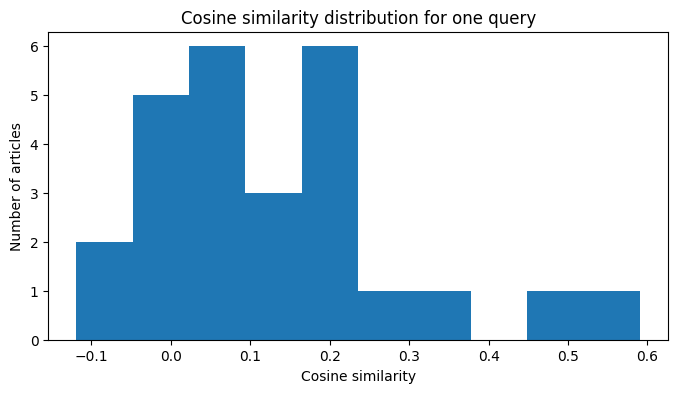

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(cosine_scores, bins=10)
plt.title("Cosine similarity distribution for one query")
plt.xlabel("Cosine similarity")
plt.ylabel("Number of articles")
plt.show()

## 5. Build a FAISS index

FAISS stores vectors and searches for nearest neighbours efficiently.

Important distinction:

- FAISS stores vectors and returns integer positions.
- Your application must map those positions back to documents, titles, categories, and metadata.
- A vector database adds persistence, metadata filtering, authentication, scaling, and APIs. FAISS is the local search engine underneath the concept.

In [9]:
# We use IndexFlatIP because the vectors are normalized.
# With normalized vectors, inner product behaves like cosine similarity.
faiss_index = build_faiss_index(document_embeddings, metric="ip")

print(f"FAISS index contains {faiss_index.ntotal} vectors.")
print(f"Embedding dimensions: {faiss_index.d}")

FAISS index contains 26 vectors.
Embedding dimensions: 384


### Search FAISS directly

FAISS returns two arrays:

- scores or distances,
- integer indices of matching vectors.

The helper below maps those vector positions back to support articles.

In [10]:
faiss_query = "How can I get my money back after cancelling?"
faiss_query_embedding = embed_texts(embedding_model, [faiss_query], normalize=True)

scores, indices = search_faiss(faiss_index, faiss_query_embedding, top_k=5)
dense_results = results_from_indices(articles, scores, indices, score_name="dense_score")

print(f"Query: {faiss_query}")
dense_results[["rank", "doc_id", "title", "category", "dense_score"]]

Query: How can I get my money back after cancelling?


,rank,doc_id,title,category,dense_score
0,1,KB-004,Request a refund for a cancelled subscription,Billing,0.5627
1,2,KB-018,Cancel a trial before billing starts,Billing,0.3800
2,3,KB-005,Update payment method after card failure,Billing,0.3343
3,4,KB-001,Reset a forgotten password,Account Access,0.3306
4,5,KB-002,Unlock an account after failed login attempts,Account Access,0.2617


## 6. Sparse vs dense search

Now compare both approaches on the same queries.

Expected pattern:

- keyword search often wins on exact identifiers,
- dense search often wins on paraphrases,
- neither is perfect.

In [11]:
def compare_sparse_dense(query: str, top_k: int = 5) -> tuple[pd.DataFrame, pd.DataFrame]:
    # Run keyword and dense search for the same query.
    sparse = keyword_search(query, articles, vectorizer, tfidf_matrix, top_k=top_k)
    dense = dense_search(query, embedding_model, faiss_index, articles, top_k=top_k)
    return sparse, dense

test_query = "I switched phones and lost my authentication app"
sparse, dense = compare_sparse_dense(test_query, top_k=5)

print(f"Query: {test_query}")
print("\nKeyword search")
display(sparse[["rank", "doc_id", "title", "category", "score"]])

print("\nDense search")
display(dense[["rank", "doc_id", "title", "category", "dense_score"]])

Query: I switched phones and lost my authentication app

Keyword search


,rank,doc_id,title,category,score
2,1,KB-003,Change the phone used for two-factor authentication,Security,0.2902
25,2,KB-026,Set up single sign-on with SAML,Security,0.0000
24,3,KB-025,Why an export may omit restricted fields,Compliance,0.0000
1,4,KB-002,Unlock an account after failed login attempts,Account Access,0.0000
3,5,KB-004,Request a refund for a cancelled subscription,Billing,0.0000



Dense search


,rank,doc_id,title,category,dense_score
0,1,KB-003,Change the phone used for two-factor authentication,Security,0.5976
1,2,KB-001,Reset a forgotten password,Account Access,0.4409
2,3,KB-002,Unlock an account after failed login attempts,Account Access,0.3903
3,4,KB-010,Resolve error E2201 for expired API tokens,Troubleshooting,0.3034
4,5,KB-014,Download a copy of your personal data,Privacy,0.2888


### Exact identifiers: where keyword search can beat dense search

Dense search may understand meaning, but exact tokens are still critical in production systems.

In [12]:
identifier_query = "E1042 import failed"
sparse, dense = compare_sparse_dense(identifier_query, top_k=5)

print(f"Query: {identifier_query}")
print("\nKeyword search")
display(sparse[["rank", "doc_id", "title", "category", "score"]])

print("\nDense search")
display(dense[["rank", "doc_id", "title", "category", "dense_score"]])

Query: E1042 import failed

Keyword search


,rank,doc_id,title,category,score
8,1,KB-009,Resolve error E1042 during data upload,Troubleshooting,0.3139
1,2,KB-002,Unlock an account after failed login attempts,Account Access,0.1612
4,3,KB-005,Update payment method after card failure,Billing,0.0545
25,4,KB-026,Set up single sign-on with SAML,Security,0.0000
24,5,KB-025,Why an export may omit restricted fields,Compliance,0.0000



Dense search


,rank,doc_id,title,category,dense_score
0,1,KB-009,Resolve error E1042 during data upload,Troubleshooting,0.6218
1,2,KB-010,Resolve error E2201 for expired API tokens,Troubleshooting,0.3569
2,3,KB-025,Why an export may omit restricted fields,Compliance,0.1765
3,4,KB-022,Understand the fair-use threshold,Policy,0.1499
4,5,KB-024,Recover a deleted project,Workspace,0.1448


## 7. Hybrid search preview

Hybrid search blends sparse and dense scores. This is a preview of a topic that becomes more important when vector databases and production retrieval are introduced.

`alpha` controls the blend:

- `alpha = 0.0` means keyword only,
- `alpha = 1.0` means dense only,
- values between them blend both signals.

In [13]:
hybrid_query = "invoice has wrong GST number"

for alpha in [0.2, 0.5, 0.8]:
    print(f"\nHybrid alpha={alpha}")
    display(
        hybrid_search(
            hybrid_query,
            articles,
            vectorizer,
            tfidf_matrix,
            embedding_model,
            document_embeddings,
            alpha=alpha,
            top_k=5,
        )[["rank", "doc_id", "title", "category", "keyword_score", "dense_score", "hybrid_score"]]
    )


Hybrid alpha=0.2


,rank,doc_id,title,category,keyword_score,dense_score,hybrid_score
5,1,KB-006,Understand invoice tax details,Billing,0.2569,0.5615,1.0000
17,2,KB-018,Cancel a trial before billing starts,Billing,0.1000,0.3184,0.4383
4,3,KB-005,Update payment method after card failure,Billing,0.0926,0.3324,0.4196
9,4,KB-010,Resolve error E2201 for expired API tokens,Troubleshooting,0.0000,0.2520,0.1069
2,5,KB-003,Change the phone used for two-factor authentication,Security,0.0000,0.1805,0.0855



Hybrid alpha=0.5


,rank,doc_id,title,category,keyword_score,dense_score,hybrid_score
5,1,KB-006,Understand invoice tax details,Billing,0.2569,0.5615,1.0000
17,2,KB-018,Cancel a trial before billing starts,Billing,0.1000,0.3184,0.5119
4,3,KB-005,Update payment method after card failure,Billing,0.0926,0.3324,0.5081
9,4,KB-010,Resolve error E2201 for expired API tokens,Troubleshooting,0.0000,0.2520,0.2673
2,5,KB-003,Change the phone used for two-factor authentication,Security,0.0000,0.1805,0.2136



Hybrid alpha=0.8


,rank,doc_id,title,category,keyword_score,dense_score,hybrid_score
5,1,KB-006,Understand invoice tax details,Billing,0.2569,0.5615,1.0000
4,2,KB-005,Update payment method after card failure,Billing,0.0926,0.3324,0.5966
17,3,KB-018,Cancel a trial before billing starts,Billing,0.1000,0.3184,0.5855
9,4,KB-010,Resolve error E2201 for expired API tokens,Troubleshooting,0.0000,0.2520,0.4277
2,5,KB-003,Change the phone used for two-factor authentication,Security,0.0000,0.1805,0.3418


## 8. Evaluate retrieval with precision@k

A retrieval system should be measured before it is connected to an LLM.

`precision@3` asks:

> Of the top 3 retrieved documents, how many were labelled relevant?

This is a simple starting metric, not the full evaluation story.

In [14]:
K = 3

keyword_eval = evaluate_retriever(
    labelled_queries,
    search_function=lambda query, top_k: keyword_search(query, articles, vectorizer, tfidf_matrix, top_k=top_k),
    k=K,
)

dense_eval = evaluate_retriever(
    labelled_queries,
    search_function=lambda query, top_k: dense_search(query, embedding_model, faiss_index, articles, top_k=top_k),
    k=K,
)

hybrid_eval = evaluate_retriever(
    labelled_queries,
    search_function=lambda query, top_k: hybrid_search(
        query,
        articles,
        vectorizer,
        tfidf_matrix,
        embedding_model,
        document_embeddings,
        alpha=0.5,
        top_k=top_k,
    ),
    k=K,
)

summary = pd.DataFrame(
    {
        "retriever": ["keyword_tfidf", "dense_minilm_faiss", "hybrid_alpha_0.5"],
        f"mean_precision@{K}": [
            keyword_eval[f"precision@{K}"].mean(),
            dense_eval[f"precision@{K}"].mean(),
            hybrid_eval[f"precision@{K}"].mean(),
        ],
    }
).round(3)

summary

,retriever,mean_precision@3
0,keyword_tfidf,0.467
1,dense_minilm_faiss,0.533
2,hybrid_alpha_0.5,0.500


### Inspect per-query evaluation

The average is useful, but the failures are where learning happens. Look for queries where one retriever fails and another succeeds.

In [15]:
dense_eval

,query,relevant_doc_ids,retrieved_doc_ids,precision@3,why
0,I forgot my password and cannot sign in,"KB-001, KB-002","KB-001, KB-002, KB-003",0.667,Password recovery is primary; account lock may also matter.
1,How can I get my money back after cancelling?,"KB-004, KB-018","KB-004, KB-018, KB-005",0.667,Paraphrase of refund and cancelled subscription/trial.
2,E1042 import failed,KB-009,"KB-009, KB-010, KB-025",0.333,Exact error code should be retrieved precisely.
3,I switched phones and lost my authentication app,KB-003,"KB-003, KB-001, KB-002",0.333,Semantic match to two-factor authentication device change.
4,Why is my dashboard taking forever to load?,KB-019,"KB-019, KB-012, KB-011",0.333,Paraphrase of slow dashboard loading.
5,download my personal information,"KB-014, KB-013","KB-014, KB-013, KB-003",0.667,Data export and deletion/retention are related privacy articles.
6,change who owns the team workspace,"KB-016, KB-017","KB-016, KB-015, KB-017",0.667,Workspace ownership transfer and permissions are relevant.
7,webhook event when an order ships,"KB-020, KB-007","KB-020, KB-007, KB-008",0.667,Webhook event is primary; shipment tracking is secondary.
8,invoice has wrong GST number,KB-006,"KB-006, KB-005, KB-018",0.333,Invoice tax details and billing identity.
9,prevent secret token exposure in GitHub,"KB-021, KB-010","KB-021, KB-010, KB-023",0.667,API key safety and token rotation/expiry.


## 9. Debug a retrieval failure

Production retrieval work is mostly debugging:

- Was the right document missing from the corpus?
- Did the embedding model misunderstand the query?
- Was the query too vague?
- Did exact terms need keyword search?
- Would metadata filtering help?
- Would reranking help?

Try changing the query below and rerun the cell.

In [16]:
debug_query = "I cannot approve login because I changed my phone"

print("Keyword")
display(keyword_search(debug_query, articles, vectorizer, tfidf_matrix, top_k=5)[
    ["rank", "doc_id", "title", "category", "score"]
])

print("\nDense")
display(dense_search(debug_query, embedding_model, faiss_index, articles, top_k=5)[
    ["rank", "doc_id", "title", "category", "dense_score"]
])

print("\nHybrid")
display(hybrid_search(
    debug_query,
    articles,
    vectorizer,
    tfidf_matrix,
    embedding_model,
    document_embeddings,
    alpha=0.5,
    top_k=5,
)[["rank", "doc_id", "title", "category", "keyword_score", "dense_score", "hybrid_score"]])

Keyword


,rank,doc_id,title,category,score
2,1,KB-003,Change the phone used for two-factor authentication,Security,0.1535
0,2,KB-001,Reset a forgotten password,Account Access,0.0679
1,3,KB-002,Unlock an account after failed login attempts,Account Access,0.0671
24,4,KB-025,Why an export may omit restricted fields,Compliance,0.0000
3,5,KB-004,Request a refund for a cancelled subscription,Billing,0.0000



Dense


,rank,doc_id,title,category,dense_score
0,1,KB-003,Change the phone used for two-factor authentication,Security,0.5478
1,2,KB-001,Reset a forgotten password,Account Access,0.4911
2,3,KB-002,Unlock an account after failed login attempts,Account Access,0.3752
3,4,KB-023,Change notification preferences,Account Settings,0.2610
4,5,KB-010,Resolve error E2201 for expired API tokens,Troubleshooting,0.2305



Hybrid


,rank,doc_id,title,category,keyword_score,dense_score,hybrid_score
2,1,KB-003,Change the phone used for two-factor authentication,Security,0.1535,0.5478,1.0000
0,2,KB-001,Reset a forgotten password,Account Access,0.0679,0.4911,0.6778
1,3,KB-002,Unlock an account after failed login attempts,Account Access,0.0671,0.3752,0.5869
22,4,KB-023,Change notification preferences,Account Settings,0.0000,0.2610,0.2811
9,5,KB-010,Resolve error E2201 for expired API tokens,Troubleshooting,0.0000,0.2305,0.2579


## 10. Optional: hosted OpenAI embedding comparison

This section is optional and safe to skip.

Why include it?

- local embeddings are good for learning and zero-cost demos,
- hosted embeddings are common in production systems,
- model choice should be tested on the actual corpus.

**COST NOTE:** This cell embeds only a handful of short texts. The cost should be far below `$0.01`.

In [17]:
openai_model_name = os.getenv("OPENAI_EMBEDDING_MODEL", "text-embedding-3-small")

sample_texts = articles["searchable_text"].head(5).tolist()
rough_token_estimate = sum(len(text.split()) for text in sample_texts) * 1.3
estimated_cost = estimate_openai_embedding_cost(int(rough_token_estimate), price_per_million_tokens=0.02)

print(f"Optional OpenAI model: {openai_model_name}")
print(f"Rough token estimate: {int(rough_token_estimate)}")
print(f"Estimated cost at $0.02 / 1M tokens: ${estimated_cost:.8f}")

try:
    # COST NOTE: Optional tiny hosted embedding call, far below $0.01 for this sample.
    openai_embeddings = openai_embed_texts(sample_texts, model_name=openai_model_name)
    print("OpenAI embedding matrix shape:", openai_embeddings.shape)
except Exception as exc:
    print("Skipping optional OpenAI comparison.")
    print(exc)

Optional OpenAI model: text-embedding-3-small
Rough token estimate: 279
Estimated cost at $0.02 / 1M tokens: $0.00000558


Skipping optional OpenAI comparison.
Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-your-****here. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}


## 11. Save and reload a FAISS index

This is optional, but useful to show that an index can be stored and reused.

In production, storing the index is not enough. You must also store the document metadata and maintain ID alignment.

In [18]:
import faiss

index_path = DATA_DIR / "support_articles_minilm.index"

faiss.write_index(faiss_index, str(index_path))
reloaded_index = faiss.read_index(str(index_path))

print(f"Saved index to: {index_path}")
print(f"Reloaded index contains {reloaded_index.ntotal} vectors.")

Saved index to: data/support_articles_minilm.index
Reloaded index contains 26 vectors.


## Exercises

### Exercise 1 — Add articles

Add three new rows to `data/support_articles.csv`:

- one with an exact error code,
- one with paraphrased policy language,
- one with a confusing title.

Rerun the notebook and compare keyword vs dense retrieval.

### Exercise 2 — Tune hybrid search

Change `alpha` to `0.1`, `0.3`, `0.7`, and `0.9`. Which queries improve? Which get worse?

### Exercise 3 — Create a “no answer found” case

Ask a query that has no correct article in the corpus. Look at the top score. What threshold would you use to avoid giving irrelevant context to an LLM?

### Exercise 4 — Try another embedding model

Change the model name to another sentence-transformers model. Recompute precision@3. Did better model quality actually improve this dataset?

## Closing summary

You built the pieces that make retrieval possible:

- sparse retrieval with TF-IDF,
- dense embeddings with MiniLM,
- similarity ranking,
- FAISS vector indexing,
- sparse vs dense comparison,
- hybrid search,
- precision@k evaluation.

Next, these ideas grow into vector databases with persistence, metadata filtering, cloud indexes, and eventually full text RAG pipelines.